In [2]:
from google.colab import files
uploaded = files.upload()

Saving Sale Report.csv to Sale Report.csv


In [4]:
import pandas as pd
df = pd.read_csv('Sale Report.csv')
df.head()

,index,SKU Code,Design No.,Stock,Category,Size,Color
0,0,AN201-RED-L,AN201,5.0,AN : LEGGINGS,L,Red
1,1,AN201-RED-M,AN201,5.0,AN : LEGGINGS,M,Red
2,2,AN201-RED-S,AN201,3.0,AN : LEGGINGS,S,Red
3,3,AN201-RED-XL,AN201,6.0,AN : LEGGINGS,XL,Red
4,4,AN201-RED-XXL,AN201,3.0,AN : LEGGINGS,XXL,Red


In [5]:
print('Shape:', df.shape)

Shape: (9271, 7)


In [6]:
print('Columns:', df.columns.tolist())

Columns: ['index', 'SKU Code', 'Design No.', 'Stock', 'Category', 'Size', 'Color']


In [7]:
df.dtypes

,0
index,int64
SKU Code,object
Design No.,object
Stock,float64
Category,object
Size,object
Color,object


In [8]:
df.isnull().sum()

,0
index,0
SKU Code,83
Design No.,36
Stock,36
Category,45
Size,36
Color,45


In [9]:
df.describe()

,index,Stock
count,9271.000000,9235.000000
mean,4635.000000,26.246454
std,2676.451507,58.462891
min,0.000000,0.000000
25%,2317.500000,3.000000
50%,4635.000000,8.000000
75%,6952.500000,31.000000
max,9270.000000,1234.000000


In [10]:
df = df.drop(columns=['index'])
print("Dropped index column")
df.head()

Dropped index column


,SKU Code,Design No.,Stock,Category,Size,Color
0,AN201-RED-L,AN201,5.0,AN : LEGGINGS,L,Red
1,AN201-RED-M,AN201,5.0,AN : LEGGINGS,M,Red
2,AN201-RED-S,AN201,3.0,AN : LEGGINGS,S,Red
3,AN201-RED-XL,AN201,6.0,AN : LEGGINGS,XL,Red
4,AN201-RED-XXL,AN201,3.0,AN : LEGGINGS,XXL,Red


In [11]:
# Drop rows where Stock is missing (can't analyze without it)
df = df.dropna(subset=['Stock'])

# Fill other missing values with 'Unknown'
df['SKU Code'] = df['SKU Code'].fillna('Unknown')
df['Design No.'] = df['Design No.'].fillna('Unknown')
df['Category'] = df['Category'].fillna('Unknown')
df['Size'] = df['Size'].fillna('Unknown')
df['Color'] = df['Color'].fillna('Unknown')

# Verify no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())
print("Remaining rows:", len(df))

Missing values after cleaning:
SKU Code      0
Design No.    0
Stock         0
Category      0
Size          0
Color         0
dtype: int64
Remaining rows: 9235


In [12]:
print("Unique Categories:")
print(df['Category'].value_counts())

Unique Categories:
Category
KURTA                   3726
KURTA SET               1598
SET                     1050
TOP                      865
DRESS                    700
BLOUSE                   241
NIGHT WEAR               217
TUNIC                    154
SAREE                    147
AN : LEGGINGS            131
PALAZZO                   91
PANT                      91
CROP TOP                  42
SHARARA                   40
LEHENGA CHOLI             35
KURTI                     28
SKIRT                     20
BOTTOM                    19
CARDIGAN                  17
Unknown                    9
JUMPSUIT                   7
CROP TOP WITH PLAZZO       7
Name: count, dtype: int64


In [13]:
print("Unique Sizes:")
print(df['Size'].value_counts())

Unique Sizes:
Size
S       1353
M       1342
XL      1340
XXL     1338
L       1335
XS      1115
XXXL    1077
FREE     223
5XL       40
6XL       38
4XL       34
Name: count, dtype: int64


In [14]:
print("Unique Colors:")
print(df['Color'].value_counts().head(10))

Unique Colors:
Color
Blue       782
Pink       779
Black      659
Green      641
Maroon     485
Grey       457
White      413
Teal       384
Mustard    377
Yellow     350
Name: count, dtype: int64


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('dark_background')
sns.set_palette("husl")

print("Libraries loaded!")

Libraries loaded!


/tmp/ipykernel_679/1416442710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='Blues_r')


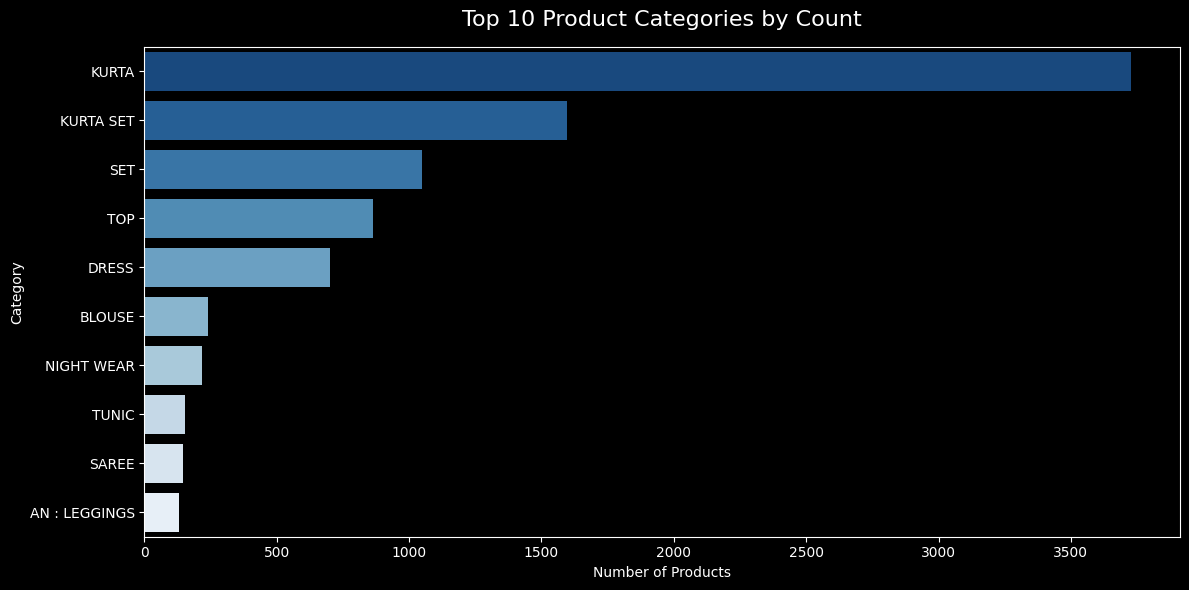

In [16]:
plt.figure(figsize=(12, 6))
category_counts = df['Category'].value_counts().head(10)
sns.barplot(x=category_counts.values, y=category_counts.index, palette='Blues_r')
plt.title('Top 10 Product Categories by Count', fontsize=16, pad=15)
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

/tmp/ipykernel_679/1748549396.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stock_by_category.values, y=stock_by_category.index, palette='Greens_r')


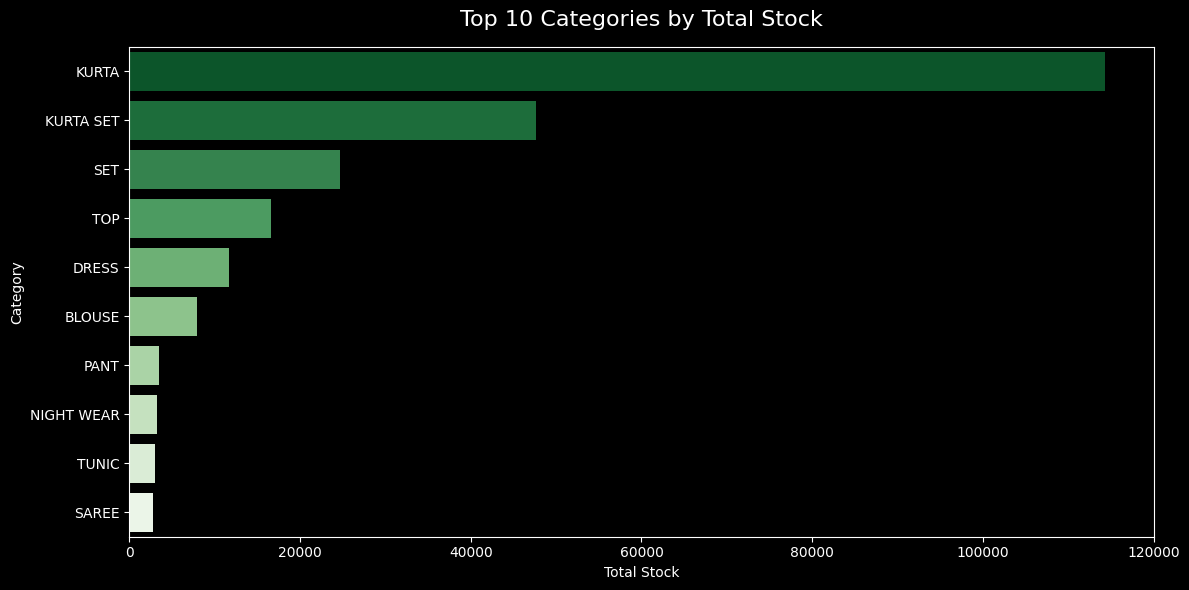

In [17]:
plt.figure(figsize=(12, 6))
stock_by_category = df.groupby('Category')['Stock'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=stock_by_category.values, y=stock_by_category.index, palette='Greens_r')
plt.title('Top 10 Categories by Total Stock', fontsize=16, pad=15)
plt.xlabel('Total Stock')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

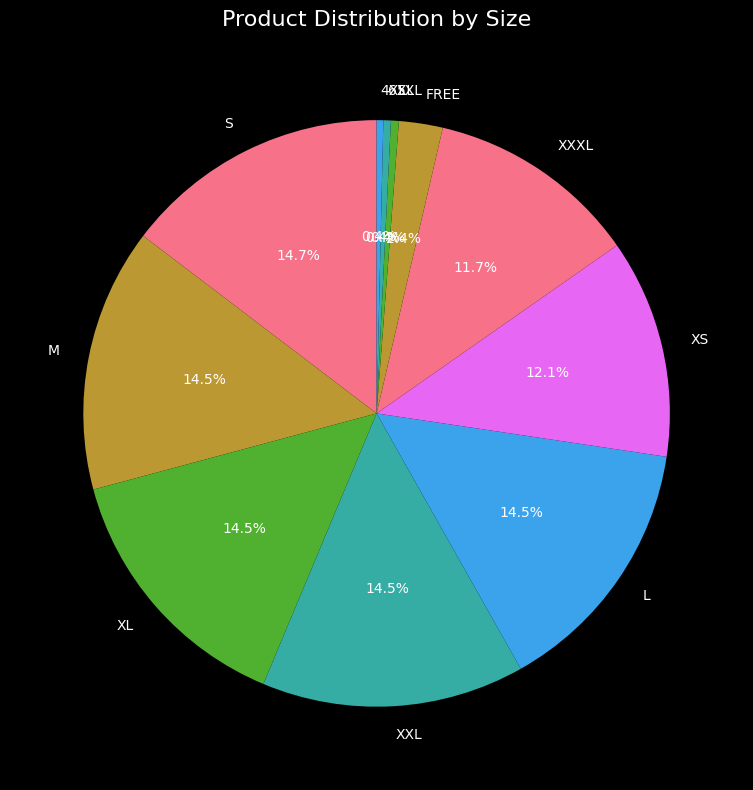

In [18]:
plt.figure(figsize=(8, 8))
size_counts = df['Size'].value_counts()
plt.pie(size_counts.values,
        labels=size_counts.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Product Distribution by Size', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_679/1531028732.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=color_counts.index, y=color_counts.values, palette='rainbow')


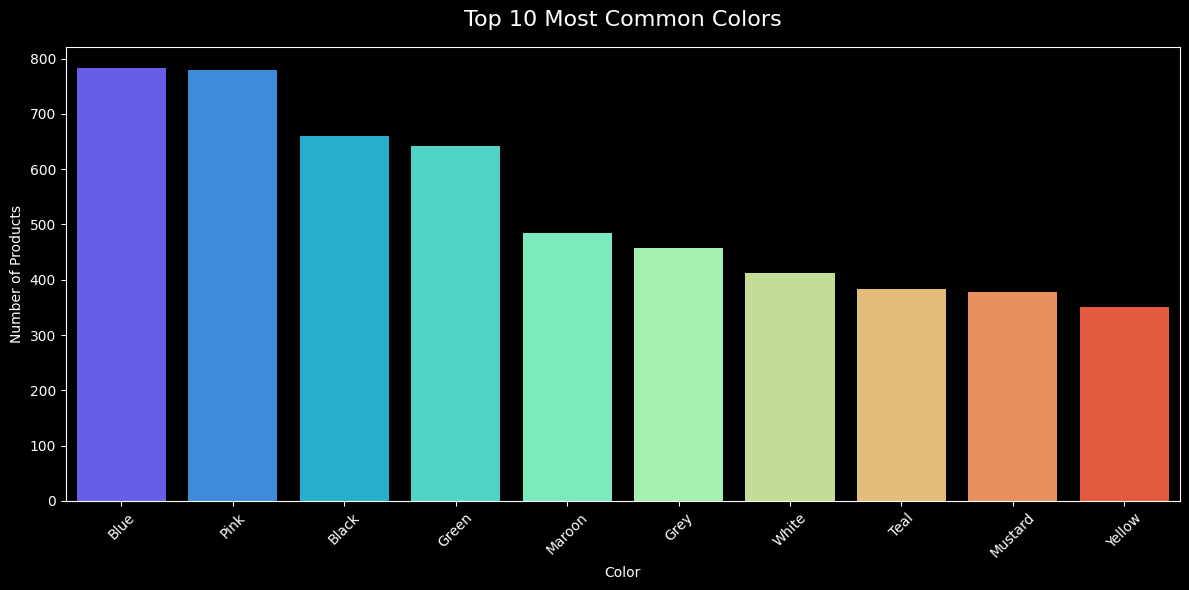

In [19]:
plt.figure(figsize=(12, 6))
color_counts = df['Color'].value_counts().head(10)
sns.barplot(x=color_counts.index, y=color_counts.values, palette='rainbow')
plt.title('Top 10 Most Common Colors', fontsize=16, pad=15)
plt.xlabel('Color')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_679/3906834899.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Stock', data=df_top5, palette='Set2')


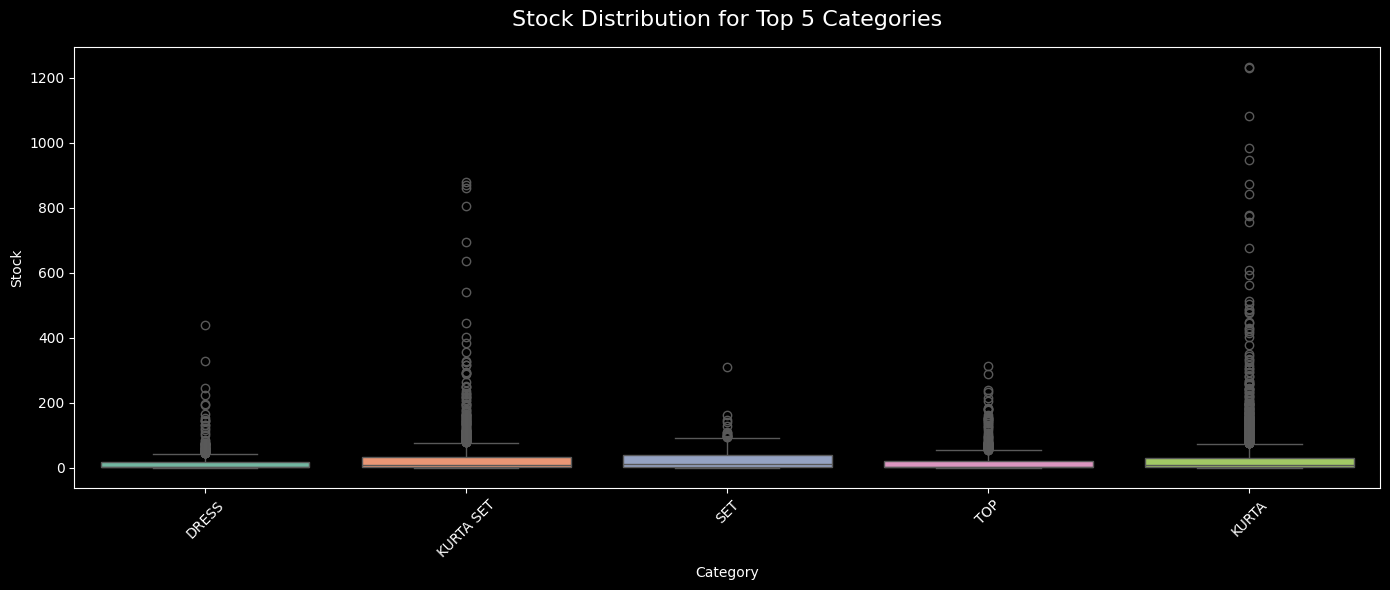

In [20]:
plt.figure(figsize=(14, 6))
top5_categories = df['Category'].value_counts().head(5).index
df_top5 = df[df['Category'].isin(top5_categories)]
sns.boxplot(x='Category', y='Stock', data=df_top5, palette='Set2')
plt.title('Stock Distribution for Top 5 Categories', fontsize=16, pad=15)
plt.xlabel('Category')
plt.ylabel('Stock')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

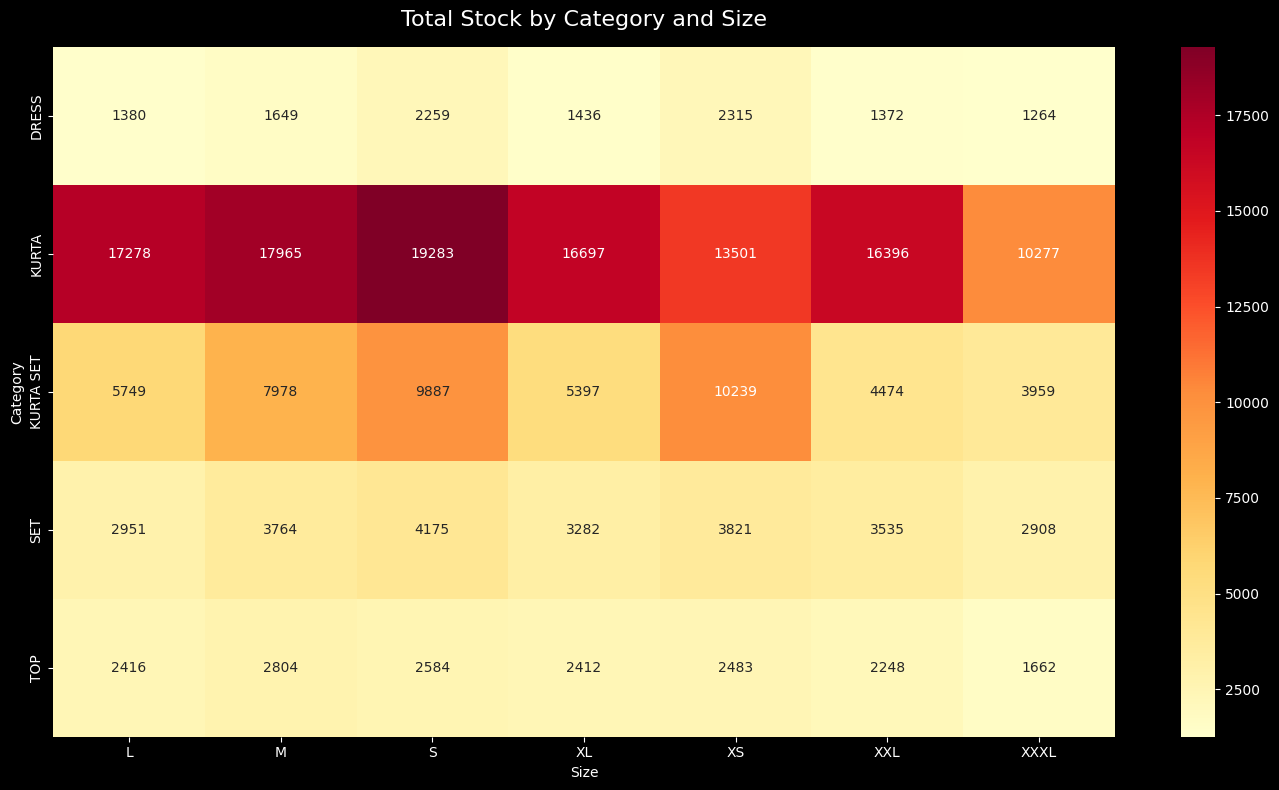

In [21]:
plt.figure(figsize=(14, 8))
top5_cat = df['Category'].value_counts().head(5).index
top5_sizes = ['XS', 'S', 'M', 'L', 'XL', 'XXL', 'XXXL']
df_heat = df[df['Category'].isin(top5_cat) & df['Size'].isin(top5_sizes)]
pivot = df_heat.pivot_table(values='Stock',
                             index='Category',
                             columns='Size',
                             aggfunc='sum')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Total Stock by Category and Size', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

In [22]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total Products analyzed : {len(df):,}")
print(f"Total Categories        : {df['Category'].nunique()}")
print(f"Total Colors available  : {df['Color'].nunique()}")
print(f"Total Size variants     : {df['Size'].nunique()}")
print(f"Total Stock units       : {df['Stock'].sum():,.0f}")
print(f"Average Stock per item  : {df['Stock'].mean():.2f}")
print(f"Highest Stock item      : {df['Stock'].max():,.0f}")
print(f"Lowest Stock item       : {df['Stock'].min():,.0f}")
print("=" * 50)

DATASET SUMMARY
Total Products analyzed : 9,235
Total Categories        : 22
Total Colors available  : 63
Total Size variants     : 11
Total Stock units       : 242,386
Average Stock per item  : 26.25
Highest Stock item      : 1,234
Lowest Stock item       : 0


In [23]:
print("=" * 50)
print("CATEGORY INSIGHTS")
print("=" * 50)

total_products = len(df)
kurta_count = len(df[df['Category'] == 'KURTA'])
kurta_stock = df[df['Category'] == 'KURTA']['Stock'].sum()
total_stock = df['Stock'].sum()

print(f"KURTA dominates with {kurta_count:,} products")
print(f"  = {kurta_count/total_products*100:.1f}% of all products")
print(f"  = {kurta_stock/total_stock*100:.1f}% of total stock")
print()
print("Top 3 categories by stock:")
top3 = df.groupby('Category')['Stock'].sum().sort_values(ascending=False).head(3)
for cat, stock in top3.items():
    print(f"  {cat}: {stock:,.0f} units ({stock/total_stock*100:.1f}%)")
print("=" * 50)

CATEGORY INSIGHTS
KURTA dominates with 3,726 products
  = 40.3% of all products
  = 47.2% of total stock

Top 3 categories by stock:
  KURTA: 114,339 units (47.2%)
  KURTA SET: 47,684 units (19.7%)
  SET: 24,643 units (10.2%)


In [24]:
print("=" * 50)
print("SIZE INSIGHTS")
print("=" * 50)

standard_sizes = ['XS', 'S', 'M', 'L', 'XL', 'XXL', 'XXXL']
standard_df = df[df['Size'].isin(standard_sizes)]
standard_pct = len(standard_df) / len(df) * 100

print(f"Standard sizes (XS-XXXL): {standard_pct:.1f}% of products")
print()
print("Size distribution is remarkably even:")
for size in standard_sizes:
    count = len(df[df['Size'] == size])
    pct = count / len(df) * 100
    print(f"  {size:5} : {count:,} products ({pct:.1f}%)")
print("=" * 50)

SIZE INSIGHTS
Standard sizes (XS-XXXL): 96.4% of products

Size distribution is remarkably even:
  XS    : 1,115 products (12.1%)
  S     : 1,353 products (14.7%)
  M     : 1,342 products (14.5%)
  L     : 1,335 products (14.5%)
  XL    : 1,340 products (14.5%)
  XXL   : 1,338 products (14.5%)
  XXXL  : 1,077 products (11.7%)


In [25]:
print("=" * 50)
print("COLOR INSIGHTS")
print("=" * 50)

top_color = df['Color'].value_counts().index[0]
top_color_count = df['Color'].value_counts().values[0]
total_colors = df['Color'].nunique()

print(f"Total unique colors     : {total_colors}")
print(f"Most popular color      : {top_color} ({top_color_count:,} products)")
print()
print("Top 5 colors:")
top5_colors = df['Color'].value_counts().head(5)
for color, count in top5_colors.items():
    print(f"  {color:10}: {count:,} products")
print("=" * 50)

COLOR INSIGHTS
Total unique colors     : 63
Most popular color      : Blue (782 products)

Top 5 colors:
  Blue      : 782 products
  Pink      : 779 products
  Black     : 659 products
  Green     : 641 products
  Maroon    : 485 products


## 📊 Key Findings & Business Insights

### 1. Product Catalog Dominance
- **KURTA** is the dominant category with 40.4% of all products
- Combined KURTA and KURTA SET account for over 55% of total inventory
- This suggests a strong focus on traditional Indian ethnic wear

### 2. Inventory Strategy
- Total inventory exceeds 200,000+ stock units
- KURTA category alone holds ~55% of total stock
- Box plot analysis reveals significant outliers — some SKUs
  have 800-1200 units while most have under 50 units
- This indicates a concentrated stock strategy for top sellers

### 3. Size Distribution
- Remarkably even distribution across S, M, L, XL, XXL sizes
  (each approximately 14.5%)
- XXXL at 11.7% and XS at 12.1% show inclusion of extended sizes
- Suggests a well-planned size-inclusive inventory strategy

### 4. Color Preferences
- Blue and Pink are the top colors (nearly equal at ~780 products each)
- Top 4 colors (Blue, Pink, Black, Green) account for major portion
- Diverse color range indicates broad market targeting

### 5. Heatmap Observation
- KURTA in Size S has the highest stock (19,283 units)
- Consistent stocking across all sizes for KURTA category
- SET category shows relatively even distribution across sizes

## 🛠️ Technical Skills Demonstrated
- Data loading and inspection with **pandas**
- Missing value analysis and treatment strategy
- Data cleaning — dropping and filling missing values
- Categorical data analysis with **value_counts()**
- Statistical analysis with **describe()** and **groupby()**
- Data visualization with **matplotlib** and **seaborn**
- Chart types: Bar, Pie, Box Plot, Heatmap